# 9. Causal Deep Learning (인과적 딥러닝)

  - [https://causalpy.readthedocs.io/en/latest/](https://causalpy.readthedocs.io/en/latest/)

In [ ]:
%pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0 --index-url https://download.pytorch.org/whl/cu121

In [ ]:
%pip install -q causalpy pytorch-lightning
%pip install -q jax jaxlib catenets
%pip install -q transformers
%pip install -q econml lightgbm ipywidgets

In [16]:
import numpy as np
import networkx as nx
import pandas as pd
from scipy import stats
import causalpy as cp

from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

import torch
import pytorch_lightning as pl

from catenets.models.torch import TARNet, SNet, FlexTENet
#from models.causal_bert_pytorch.CausalBert import CausalBertWrapper

from econml.metalearners import SLearner, XLearner
from econml.dml import CausalForestDML
from econml.dr import LinearDRLearner
from lightgbm import LGBMRegressor

import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

import json
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

In [17]:
# Set device
# 장치 설정
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

# Set random seed
# 랜덤 시드 설정
SEED = 18
np.random.seed(SEED)
pl.seed_everything(SEED)

Seed set to 18


cuda


In [18]:
COLORS = [
    '#00B0F0',
    '#FF0000',
    '#B0F000'
]

In [19]:
def plot_effect(effect_true, effect_pred, figsize=(10, 7), ylim=(5000, 22000)):
    plt.figure(figsize=figsize)
    plt.scatter(effect_true, effect_pred, color=COLORS[0])
    plt.plot(np.sort(effect_true), np.sort(effect_true), color=COLORS[1], alpha=.7, label='Perfect model')
    plt.xlabel('$True\ effect$', fontsize=14, alpha=.5)
    plt.ylabel('$Predicted\ effect$', fontsize=14, alpha=.5)
    plt.ylim(ylim[0], ylim[1])
    plt.legend()
    plt.show()

## **1. 딥러닝: 이질적 처리 효과 (HTE)**

### **1.1 데이터**

In [20]:
SAMPLE_SIZE = 5000
TRAIN_SIZE = 4500
N_FEATURES = 20

X = np.random.normal(0, 1, (SAMPLE_SIZE, N_FEATURES))
T = np.random.binomial(1, 0.5, SAMPLE_SIZE)

weights = np.random.gumbel(5, 10, (SAMPLE_SIZE, N_FEATURES - 1))

y = (50 * T * np.abs(X[:, 0])**1.2) + (weights * X[:, 1:]).sum(axis=1)

y0 = (50 * 0 * np.abs(X[:, 0])**1.2) + (weights * X[:, 1:]).sum(axis=1)
y1 = (50 * 1 * np.abs(X[:, 0])**1.2) + (weights * X[:, 1:]).sum(axis=1)

In [21]:
effect_true = y1[TRAIN_SIZE:] - y0[TRAIN_SIZE:]

### **1.2 S-Learner, X-Learner, DR-Learner 및 인과 포레스트 (벤치마크)**

  - **S-Learner (Single-Learner):**
  - **X-Learner:** 
  - **DR-Learner (Doubly-Robust Learner):** 
  - **인과 포레스트 (Causal Forest):** 

In [22]:
benchmark_models = {
    'SLearner': SLearner(overall_model=LGBMRegressor()),
    'XLearner': XLearner(models=LGBMRegressor()),
    'DRLearner': LinearDRLearner(),
    'CausalForest': CausalForestDML()
}

benchmark_results = {}


for model_name, model in benchmark_models.items():
    model.fit(
        X=X[:TRAIN_SIZE, :],
        T=T[:TRAIN_SIZE],
        Y=y[:TRAIN_SIZE]
    )

    effect_pred = model.effect(
        X[TRAIN_SIZE:]
    )

    benchmark_results[model_name] = effect_pred

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001402 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5104
[LightGBM] [Info] Number of data points in the train set: 4500, number of used features: 22
[LightGBM] [Info] Start training from score 20.369942
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000536 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 2278, number of used features: 20
[LightGBM] [Info] Start training from score 0.420480
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000517 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 2222, number of used features: 20
[LightGBM] [Info] Start train

SLearner MAPE = 3.339113509099748


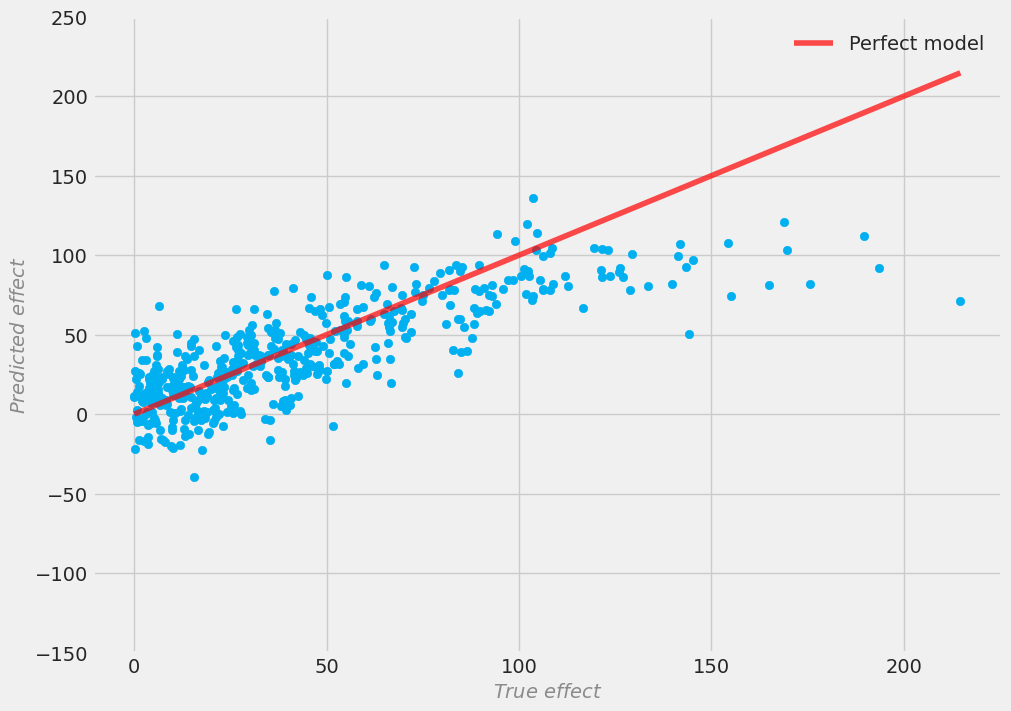

XLearner MAPE = 4.256833487010385


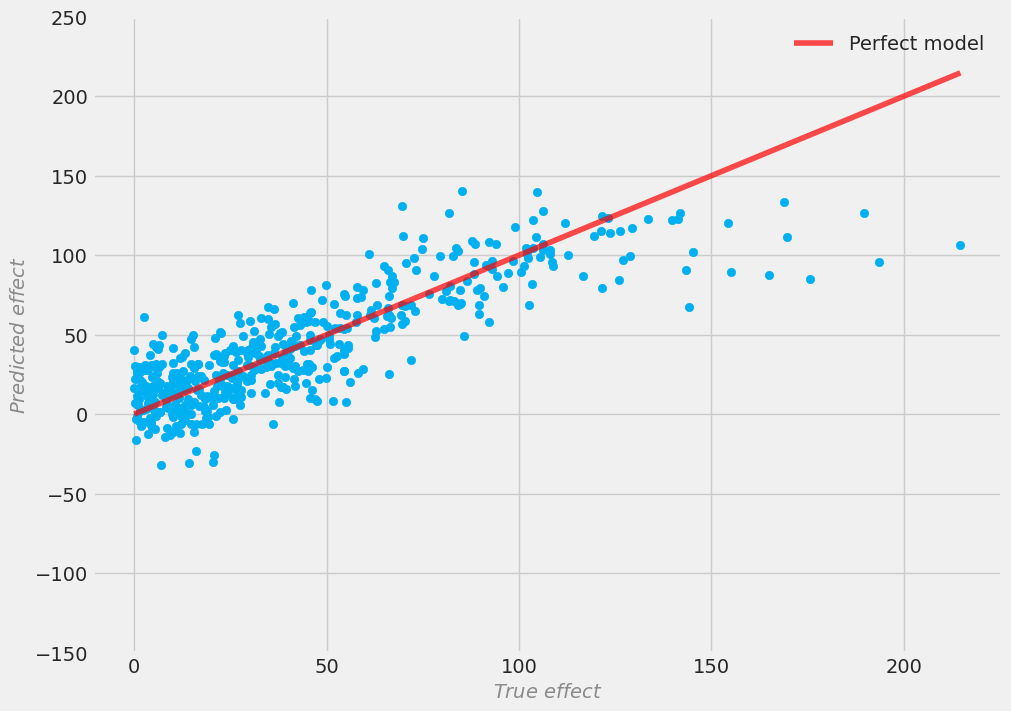

DRLearner MAPE = 8.709102589269953


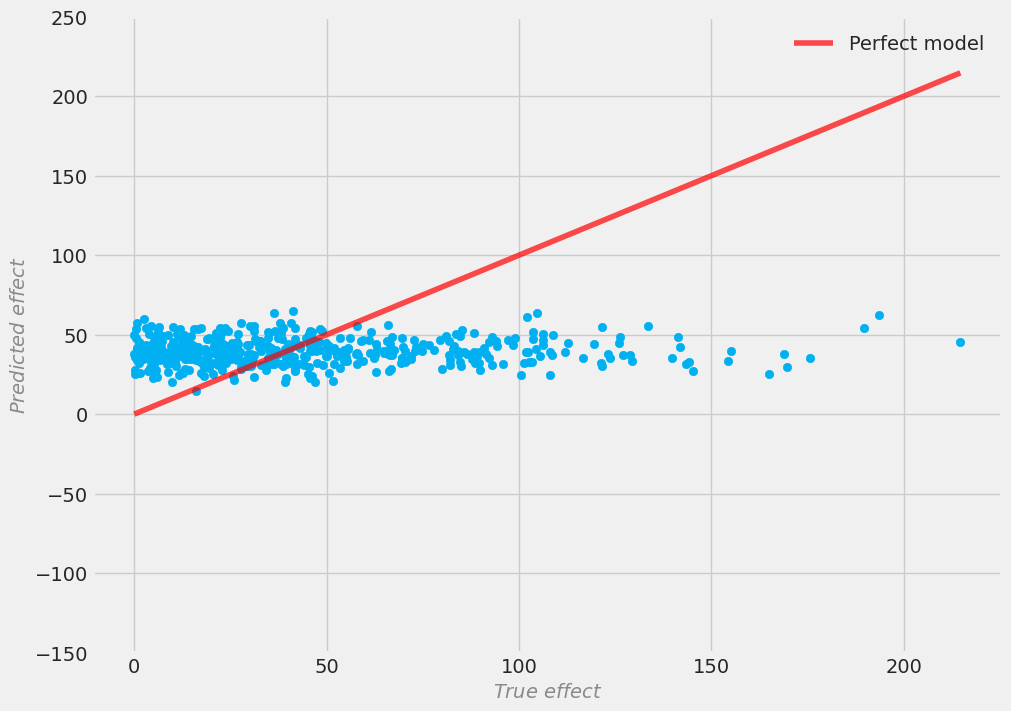

CausalForest MAPE = 3.621043001450849


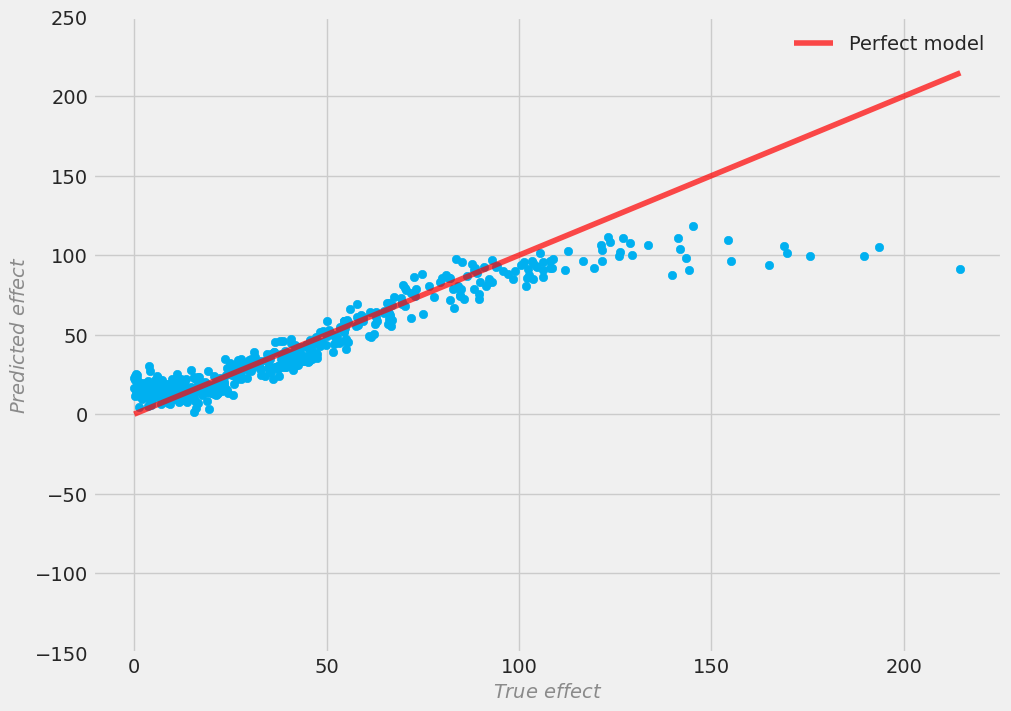

In [23]:
for model_name in benchmark_results.keys():
    effect_pred = benchmark_results[model_name]
    print(f'{model_name} MAPE = {mean_absolute_percentage_error(effect_true, effect_pred)}')

    plot_effect(
        effect_true=effect_true,
        effect_pred=effect_pred,
        ylim=(-150, 250)
    )


### **1.3 TARNet**

In [24]:
tarnet = TARNet(
    n_unit_in=X.shape[1],
    binary_y=False,
    n_units_out_prop=32,
    n_units_r=8,
    nonlin='selu',
)

tarnet.fit(
    X=X[:TRAIN_SIZE, :],
    y=y[:TRAIN_SIZE],
    w=T[:TRAIN_SIZE]
);

In [25]:
# Get predictions
# 예측값 얻기
effect_pred_tarnet = tarnet.predict(
    X=X[TRAIN_SIZE:, :]
).cpu().detach().numpy()

In [26]:
# Compute the error
# 오차 계산
mean_absolute_percentage_error(effect_true, effect_pred_tarnet)

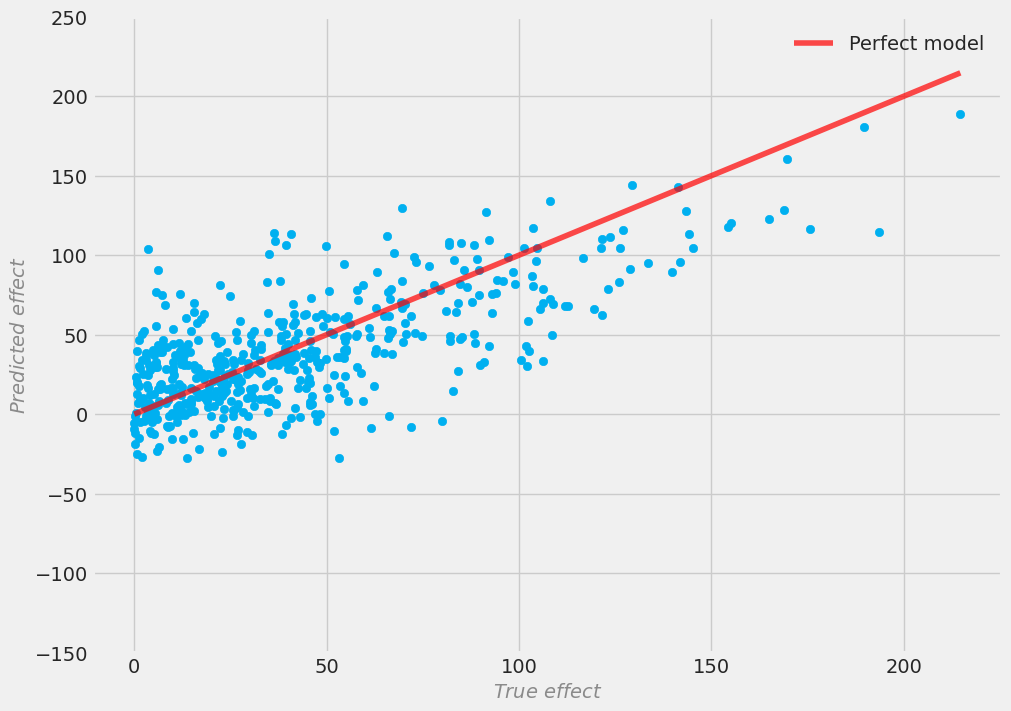

In [27]:
plot_effect(
    effect_true=effect_true,
    effect_pred=effect_pred_tarnet,
    ylim=(-150, 250)
)

### **1.4 SNet**

In [28]:
snet = SNet(
    n_unit_in=X.shape[1],
    binary_y=False,
    n_units_out_prop=32,
    n_units_r=8,
    nonlin='selu',
)

snet.fit(
    X=X[:TRAIN_SIZE, :],
    y=y[:TRAIN_SIZE],
    w=T[:TRAIN_SIZE]
);

In [29]:
effect_pred_snet = snet.predict(
    X=X[TRAIN_SIZE:, :]
).cpu().detach().numpy()

In [30]:
# Compute the error
# 오차 계산
mean_absolute_percentage_error(effect_true, effect_pred_snet)

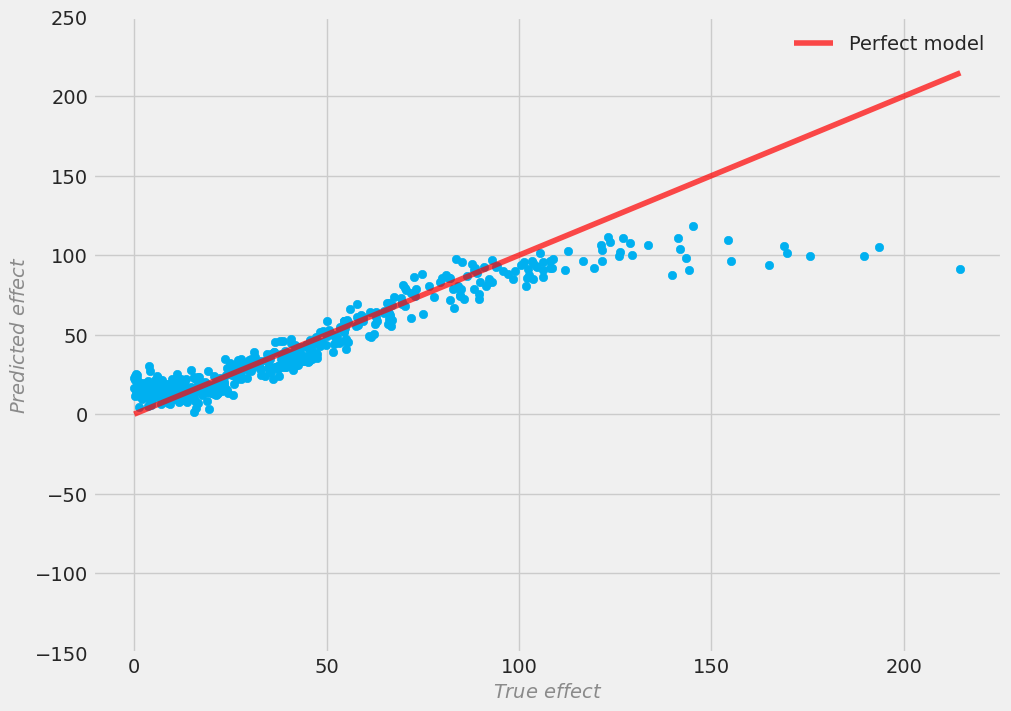

In [31]:
plot_effect(
    effect_true=effect_true,
    effect_pred=effect_pred,
    ylim=(-150, 250)
)

## **2. 인과성과 시계열: 계량경제학적 베이지안**


### **2.1 데이터**

In [33]:
# Read in the data
# 데이터 읽기
data = pd.read_csv('./data/gt_social_media_data.csv')
data.head()

,date,twitter,linkedin,tiktok,instagram
0,2022-05-15,55,9,23,59
1,2022-05-16,54,18,20,59
2,2022-05-17,54,20,23,57
3,2022-05-18,54,20,21,55
4,2022-05-19,49,23,21,52


In [34]:
# Datetime to index
# Datetime을 인덱스로
data.index = pd.to_datetime(data['date'])
data = data.drop('date', axis=1)

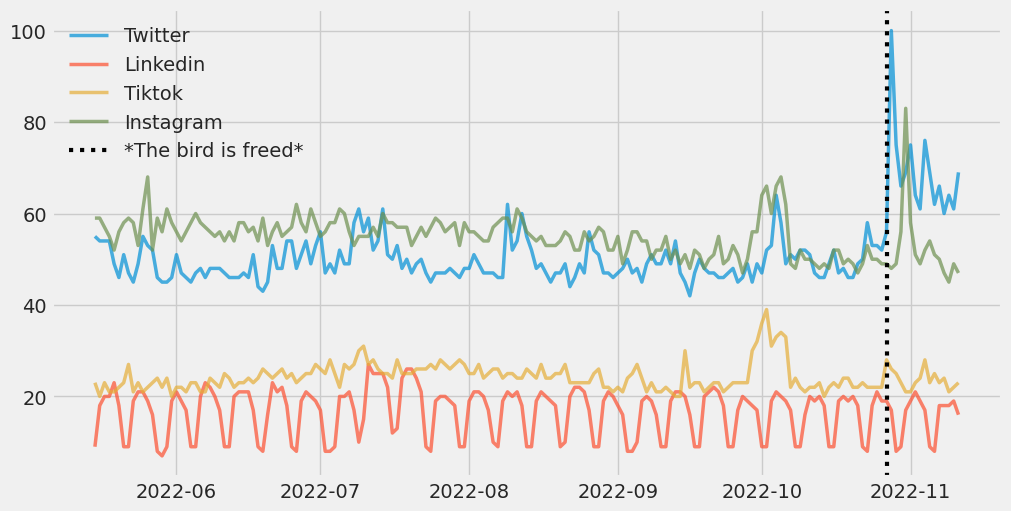

In [35]:
# Plot the data
# 데이터 시각화
plt.figure(figsize=(10, 5))

for i, series in enumerate(data.columns):
    plt.plot(data[series], label=series.title(), lw=2.5, alpha=.7)

plt.axvline(pd.to_datetime('2022-10-27'), color='black', lw=3, ls='dotted', label='*The bird is freed*')
plt.legend()
plt.show()

In [36]:
# Get the treatment time index
# 처리 시점 인덱스 얻기
treatment_index = pd.to_datetime('2022-10-28')



### **2.2 모델링**

In [37]:
# Build the model
# 모델 구축
model = cp.pymc_models.WeightedSumFitter()

# Define the model
# 모델 정의
formula = 'twitter ~ 0 + tiktok + linkedin + instagram'

# Run the experiment
# 실험 실행
results = cp.pymc_experiments.SyntheticControl(
    data,
    treatment_index,
    formula=formula,
    model=model,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 12 seconds.
Sampling: [beta, sigma, y_hat]
Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]


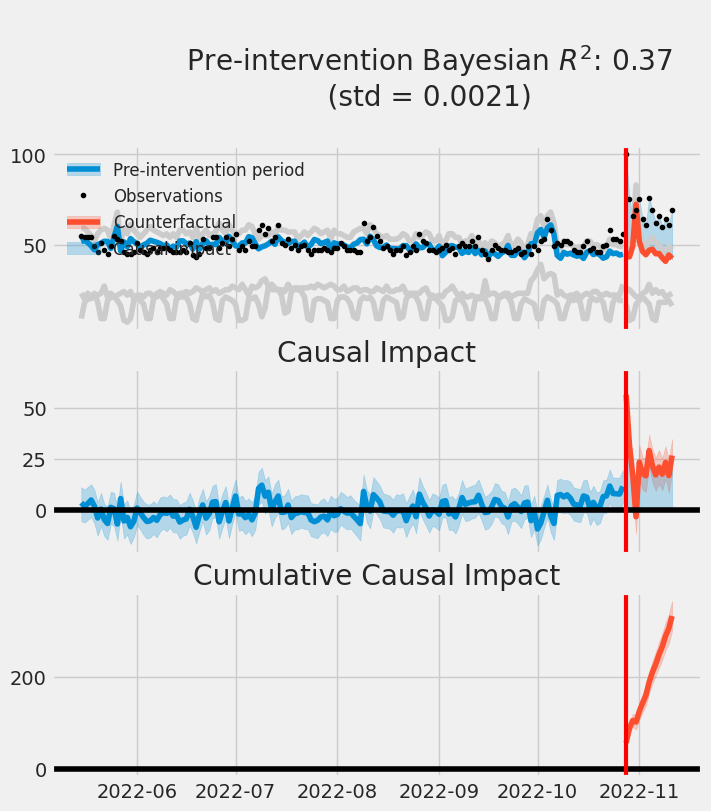

In [38]:
# Plot results
# 결과 시각화
results.plot(plot_predictors=True)
plt.show()

In [39]:
# Print results summary
# 결과 요약 출력
results.summary()

==================================Pre-Post Fit==================================
Formula: twitter ~ 0 + tiktok + linkedin + instagram
Model coefficients:
    tiktok     0.057, 94% HDI [0.0033, 0.14]
    linkedin   0.11, 94% HDI [0.036, 0.15]
    instagram  0.84, 94% HDI [0.81, 0.86]
    sigma      4.3, 94% HDI [4, 4.7]
